# poly2mask.ipynb

In [1]:
import numpy as np
import shapely.wkt as wkt
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd
from icecream import ic
import cv2
from skimage.measure import perimeter
import pyefd

# Functions

In [2]:
def pad_to_square(binary_array, pad_value=0):
    """
    Pads a 2D numpy binary array to make it square.

    Args:
        binary_array (np.ndarray): The input 2D numpy array.
        pad_value (int): The constant value used for padding (0 or 1).

    Returns:
        np.ndarray: The padded square array.
    """
    height, width = binary_array.shape
    max_dim = max(height, width)
    
    # Calculate the padding needed for each axis
    # The padding is split evenly (as possible) between "before" and "after" the original array
    pad_height = max_dim - height
    pad_width = max_dim - width
    
    # Define padding for top/bottom and left/right
    # ((top, bottom), (left, right))
    # Using floor division to distribute padding
    top_pad = pad_height // 2
    bottom_pad = pad_height - top_pad
    left_pad = pad_width // 2
    right_pad = pad_width - left_pad
    
    pad_width_tuple = ((top_pad, bottom_pad), (left_pad, right_pad))
    
    # Pad the array using the 'constant' mode with the specified value
    padded_array = np.pad(binary_array, pad_width=pad_width_tuple, mode='constant', constant_values=pad_value)
    
    return padded_array

# # --- Example Usage ---
# # Create a non-square 2D binary array
# original_array = np.array([
#     [1, 0, 1],
#     [0, 1, 0]
# ])

# print("Original Array Shape:", original_array.shape)
# print(original_array)

# # Pad the array to make it square
# square_array = pad_to_square(original_array, pad_value=0)

# print("\nSquared Array Shape:", square_array.shape)
# print(square_array)

# # Another example with a different aspect ratio
# original_array_2 = np.array([
#     [1, 1],
#     [0, 0],
#     [1, 1],
#     [0, 0]
# ])

# print("\nOriginal Array 2 Shape:", original_array_2.shape)
# print(original_array_2)

# # Pad the second array
# square_array_2 = pad_to_square(original_array_2, pad_value=1)

# print("\nSquared Array 2 Shape:", square_array_2.shape)
# print(square_array_2)

# Main

In [3]:
efd_order = 55

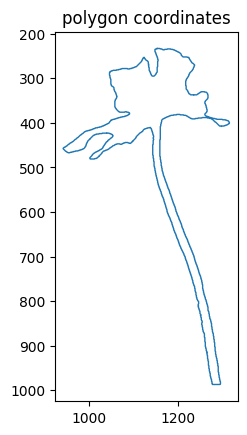

In [4]:
# Read WKT from SQLite and convert to Shapely geometry
df = pd.read_sql(
    "SELECT detection_id, poly_wkt FROM detections WHERE detection_id=17;", 
    sqlite3.connect('sam3_detections.sqlite3')
)
wkt_str = df.at[0, 'poly_wkt']
poly = wkt.loads(wkt_str)
x, y = poly.exterior.xy

# Plot
fig, ax = plt.subplots()
ax.plot(x, y, linewidth=1)
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.set_aspect('equal')
ax.set_title('polygon coordinates');

ic| coords[:10]: array([[211,   0],
                        [210,   1],
                        [208,   1],
                        [207,   2],
                        [206,   2],
                        [206,   7],
                        [207,   8],
                        [207,   9],
                        [208,  10],
                        [208,  12]], dtype=int32)
ic| np.max(coords, axis=0): array([373, 754], dtype=int32)
ic| coords[:10]: array([[211,   0],
                        [210,   1],
                        [208,   1],
                        [207,   2],
                        [206,   2],
                        [206,   7],
                        [207,   8],
                        [207,   9],
                        [208,  10],
                        [208,  12]], dtype=int32)
ic| np.max(coords, axis=0): array([373, 754], dtype=int32)
ic| min(xs): np.int32(0)
    max(xs): np.int32(373)
    min(ys): np.int32(0)
    max(ys): np.int32(754)


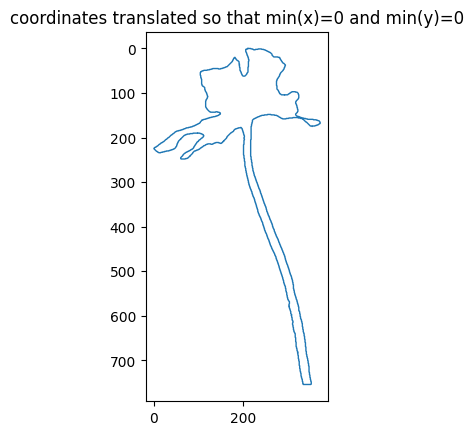

In [5]:
coords = np.array(poly.exterior.coords, dtype=np.int32)
coords = coords - np.min(coords, axis=0)
ic(coords[:10])
ic(np.max(coords, axis=0))

# coords = coords + 10
ic(coords[:10])
ic(np.max(coords, axis=0))
xs, ys = coords.T
ic(min(xs), max(xs), min(ys), max(ys))

fig, ax = plt.subplots()
ax.plot(xs, ys, linewidth=1)
ax.set_aspect('equal')
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.set_title('coordinates translated so that min(x)=0 and min(y)=0');

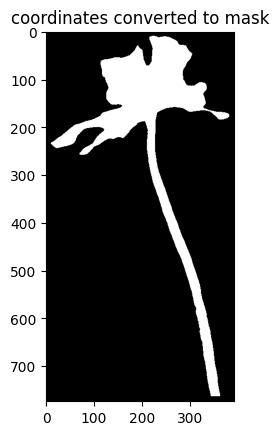

In [6]:
mask = cv2.fillPoly(np.zeros((max(ys), max(xs)), dtype=np.uint8), [coords], 1)
mask = np.pad(mask, pad_width=10, mode='constant', constant_values=0)

fig, ax = plt.subplots()
ax.imshow(mask, cmap='gray')
ax.set_title('coordinates converted to mask');

In [7]:
# Calculating ones in edges
arr = mask
top_ones = np.sum(arr[0, :])
bottom_ones = np.sum(arr[-1, :])
left_ones = np.sum(arr[:, 0])
right_ones = np.sum(arr[:, -1])
ic(top_ones, bottom_ones, left_ones, right_ones)

ic| top_ones: np.uint64(0)
    bottom_ones: np.uint64(0)
    left_ones: np.uint64(0)
    right_ones: np.uint64(0)


(np.uint64(0), np.uint64(0), np.uint64(0), np.uint64(0))

ic| mask.shape: (774, 393)
ic| perimeter(mask, neighborhood=4): np.float64(2759.54242277373)
ic| resized_mask.shape: (1080, 548)
ic| np.max(resized_mask): np.uint8(1)
ic| perimeter(resized_mask, neighborhood=4): np.float64(4027.4795436573277)


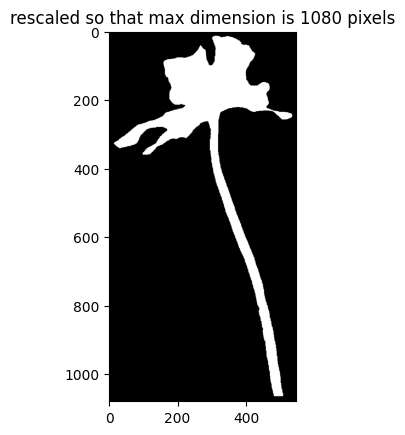

In [8]:
height, width = mask.shape
ic(mask.shape)
ic(perimeter(mask, neighborhood=4) )

target_dimension = 1080
if height > width:
    ratio = target_dimension / float(height)
else:
    ratio = target_dimension / float(width) 
new_height = int(ratio * height)
new_width = int(ratio * width)
resized_mask = cv2.resize(mask, (new_width, new_height), interpolation=cv2.INTER_AREA)
ic(resized_mask.shape)
ic(np.max(resized_mask))
ic(perimeter(resized_mask, neighborhood=4) )

fig, ax = plt.subplots()
ax.imshow(resized_mask, cmap='gray')
ax.set_title('rescaled so that max dimension is 1080 pixels');

ic| squared_mask.shape: (1080, 1080)


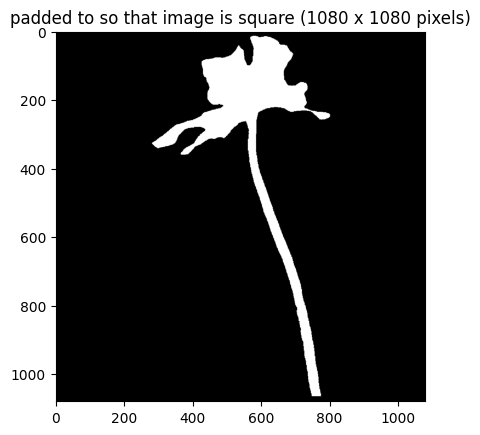

In [9]:
squared_mask = pad_to_square(resized_mask)
ic(squared_mask.shape)

fig, ax = plt.subplots()
ax.imshow(squared_mask, cmap='gray')
ax.set_title('padded to so that image is square (1080 x 1080 pixels)');

ic| contour: array([[574,  14],
                    [573,  15],
                    [570,  15],
                    ...,
                    [588,  15],
                    [584,  15],
                    [583,  14]], shape=(1761, 2), dtype=int32)


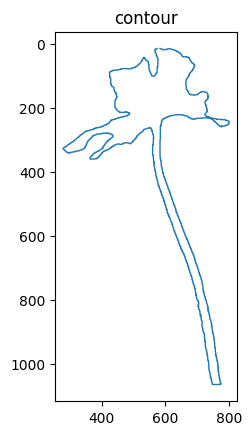

In [10]:
# Get a contour for the square_mask

import cv2 
import numpy
from pyefd import elliptic_fourier_descriptors

im = squared_mask

# Find the contours of a binary image using OpenCV.
contours, hierarchy = cv2.findContours(im, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
assert len(contours) == 1
contour = contours[0].squeeze()
ic(contour)

# Plot
xs, ys = contour.T
fig, ax = plt.subplots()
ax.plot(xs, ys, linewidth=1)
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.set_aspect('equal')
ax.set_title('contour');


In [11]:
# calculate EFD coefficients
coeffs = pyefd.elliptic_fourier_descriptors(contour, order=efd_order, normalize=False)
ic(coeffs.shape);

ic| coeffs.shape: (55, 4)


ic| reconstructed_contour: array([[-1.91764071e+01, -4.04744593e+02],
                                  [-2.44478137e+01, -3.99290130e+02],
                                  [-2.42064056e+01, -3.90371483e+02],
                                  [-2.05362715e+01, -3.78564323e+02],
                                  [-1.69200862e+01, -3.64965374e+02],
                                  [-1.63555385e+01, -3.50878849e+02],
                                  [-1.98561640e+01, -3.37935386e+02],
                                  [-2.62748188e+01, -3.28396108e+02],
                                  [-3.33938278e+01, -3.24899127e+02],
                                  [-3.93965127e+01, -3.29245160e+02],
                                  [-4.37640402e+01, -3.40812581e+02],
                                  [-4.72240337e+01, -3.55910215e+02],
                                  [-5.10402024e+01, -3.68996372e+02],
                                  [-5.62145699e+01, -3.75341025e+02],
                    

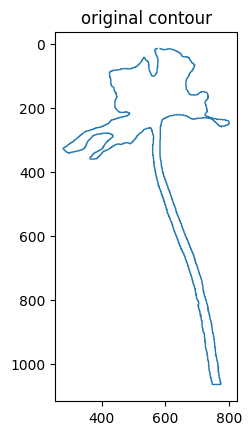

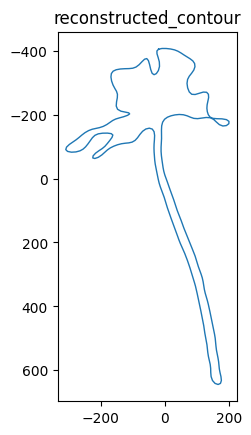

In [12]:
# Plot
fig, ax = plt.subplots()
ax.plot(xs, ys, linewidth=1)
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.set_aspect('equal')
ax.set_title('original contour');

# Reconstruct contour using EFD coefficients
reconstructed_contour = pyefd.reconstruct_contour(coeffs)
ic(reconstructed_contour)


# Plot
r_xs, r_ys = reconstructed_contour.T

fig, ax = plt.subplots()
ax.plot(r_xs, r_ys, linewidth=1)
ax.set_aspect('equal')
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.set_title('reconstructed_contour');



In [13]:
from shapely.affinity import translate
from shapely.geometry import Polygon

def center_polygon(p: Polygon) -> Polygon:
    "Returns a shaply Polygon with centroid translated to (0, 0)"
    centroid = p.centroid
    return translate(p, xoff=-centroid.x, yoff=-centroid.y)

def calc_iou(p1: Polygon, p2: Polygon) -> float:
    "Returns IoU for 2 shapely Polygons"
    try:
        intersection = p1.intersection(p2)
    except:
        return -1
    union = p1.area + p2.area - intersection.area 
    return intersection.area / union


In [14]:
# Convert 'contour' to shapely polygon
p1 = Polygon(contour)
p2 = Polygon(reconstructed_contour)

cp1 = center_polygon(p1)
ic(cp1.centroid)

cp2 = center_polygon(p2)
ic(cp2.centroid)

iou = calc_iou(cp1, cp2)
ic(iou);

ic| cp1.centroid: <POINT (3.661e-14 7.778e-14)>
ic| cp2.centroid: <POINT (-6.872e-14 -1.324e-14)>
ic| iou: 0.9620609898890544


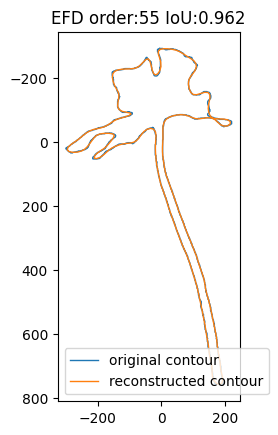

In [15]:
# plot original contour and reconstructed contour in the same axes
fig, ax = plt.subplots()
fig.set

xs, ys = cp1.exterior.coords.xy
plt.plot(xs, ys, label='original contour', linewidth=1)
xs, ys = cp2.exterior.coords.xy
plt.plot(xs, ys, label='reconstructed contour', linewidth=1)
ax.set_aspect('equal')
ax.invert_yaxis()  # Invert y-axis to match image coordinates
ax.legend(loc='best')
ax.set_title(f'EFD order:{efd_order} IoU:{iou:.3f}');


In [16]:
import numpy as np
import cv2
from shapely.geometry import Polygon
from shapely import affinity

def polygon_to_mask2(poly: Polygon, size: int = 1080, padding: int = 10) -> np.ndarray:
    """
    Rescale and translate a Shapely polygon to fit a centered box with strict padding.

    Uses the bounding box center rather than the centroid to ensure that 
    the 10-pixel padding is strictly respected on all four edges.

    Args:
        poly: The Shapely Polygon object to be transformed.
        size: The width and height of the output square mask in pixels.
        padding: The required zero-padding on all four edges.

    Returns:
        A NumPy array of shape (size, size) representing the binary mask.
    """
    # 1. Calculate current bounding box dimensions
    minx, miny, maxx, maxy = poly.bounds
    width = maxx - minx
    height = maxy - miny
    
    if width == 0 or height == 0:
        return np.zeros((size, size), dtype=np.uint8)

    # 2. Calculate scale factor to fit the safe zone (size - 2 * padding)
    safe_limit = size - (2 * padding)
    scale_factor = safe_limit / max(width, height)

    # 3. Center based on the BOUNDING BOX center, not the centroid
    # This ensures the furthest points in any direction are equidistant from the edges
    bbox_center_x = (minx + maxx) / 2.0
    bbox_center_y = (miny + maxy) / 2.0
    
    # Move BBox center to (0,0)
    poly_centered = affinity.translate(poly, xoff=-bbox_center_x, yoff=-bbox_center_y)
    
    # Scale at the origin (0,0)
    poly_scaled = affinity.scale(
        poly_centered, xfact=scale_factor, yfact=scale_factor, origin=(0, 0)
    )

    # 4. Shift to the absolute center of the image coordinate system
    # For a 1080px image, the midpoint is 540.0
    img_midpoint = size / 2.0
    poly_final = affinity.translate(poly_scaled, xoff=img_midpoint, yoff=img_midpoint)

    # 5. Rasterize
    mask = np.zeros((size, size), dtype=np.uint8)
    # Use np.int32 for OpenCV fillPoly; coordinates are rounded to nearest pixel
    coords = np.array(poly_final.exterior.coords, dtype=np.int32)
    cv2.fillPoly(mask, [coords], 1)
    
    return mask


In [17]:
def check_padding(binary_image):
    """ Check for padding on edges of a binary image."""
    arr = mask
    top_ones = np.sum(arr[0, :])
    bottom_ones = np.sum(arr[-1, :])
    left_ones = np.sum(arr[:, 0])
    right_ones = np.sum(arr[:, -1])
    ic(top_ones, bottom_ones, left_ones, right_ones)

In [44]:
def calc_best_efd_order(poly: Polygon) -> dict:
    """ 
    Calculates the 'best' efd order parameter for a detected object.
    efd_order is increased until the IoU for ploy and reconstructed_poly decreases.
    
    Input:
      poly: shapely polygon for a detected object
      
    Returns:
      a dict containing efd_order and iou
    """ 
    # transform the polygon into an 1080x1080 image of a binary mask 
    mask = polygon_to_mask2(poly)
    check_padding(mask)
    
    # contour the mask using opencv
    # Find the contours of a binary image using OpenCV.
    contours, hierarchy = cv2.findContours(im, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    assert len(contours) == 1 # ONLY 1 CONTOUR IS EXPECTED
    contour = contours[0].squeeze()
    
    results = []
    for efd_order in range(30, 61):
        # calculate EFD coefficients
        coeffs = pyefd.elliptic_fourier_descriptors(contour, order=efd_order, normalize=False)
        reconstructed_contour = pyefd.reconstruct_contour(coeffs)

        # Convert 'contour' to shapely polygon
        p1 = Polygon(contour)
        p2 = Polygon(reconstructed_contour)

        cp1 = center_polygon(p1)
        ic(cp1.centroid)

        cp2 = center_polygon(p2)
        ic(cp2.centroid)

        iou = calc_iou(cp1, cp2)
        ic(iou);
        
        results.append({'efd_order':efd_order, 'iou': iou})        
        
    return results

# Usage example:

wkt_str = df.at[0, 'poly_wkt']
poly = wkt.loads(wkt_str)
results = calc_best_efd_order(poly)
df_results = pd.DataFrame(results)
df_results

ic| top_ones: np.uint64(0)
    bottom_ones: np.uint64(0)
    left_ones: np.uint64(0)
    right_ones: np.uint64(0)
ic| cp1.centroid: <POINT (3.661e-14 7.778e-14)>
ic| cp2.centroid: <POINT (-1.916e-14 -1.055e-14)>
ic| iou: 0.9076252000855555
ic| cp1.centroid: <POINT (3.661e-14 7.778e-14)>
ic| cp2.centroid: <POINT (-1.436e-14 3.067e-14)>
ic| iou: 0.9221015361521574
ic| cp1.centroid: <POINT (3.661e-14 7.778e-14)>
ic| cp2.centroid: <POINT (-2.813e-14 3.823e-14)>
ic| iou: 0.926269417487006
ic| cp1.centroid: <POINT (3.661e-14 7.778e-14)>
ic| cp2.centroid: <POINT (4.114e-15 -1.794e-13)>
ic| iou: 0.9329028175572078
ic| cp1.centroid: <POINT (3.661e-14 7.778e-14)>
ic| cp2.centroid: <POINT (1.837e-13 1.804e-13)>
ic| iou: 0.935019922471359
ic| cp1.centroid: <POINT (3.661e-14 7.778e-14)>
ic| cp2.centroid: <POINT (6.207e-15 1.869e-13)>
ic| iou: 0.9343501036092432
ic| cp1.centroid: <POINT (3.661e-14 7.778e-14)>
ic| cp2.centroid: <POINT (6.619e-14 1.039e-13)>
ic| iou: 0.9340950078246043
ic| cp1.centroi

,efd_order,iou
0,30,0.907625
1,31,0.922102
2,32,0.926269
3,33,0.932903
4,34,0.935020
5,35,0.934350
6,36,0.934095
7,37,0.945581
8,38,0.948331
9,39,0.948924


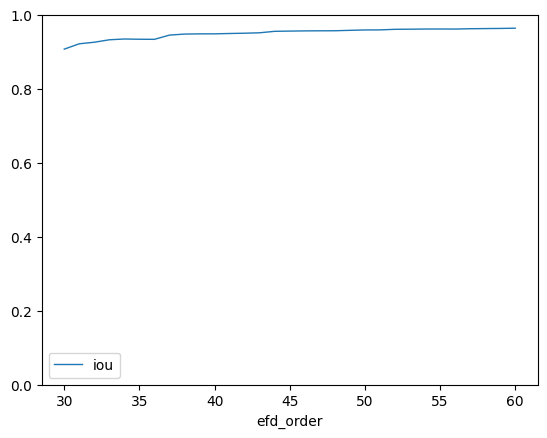

In [45]:
df_results.plot(x='efd_order', y='iou', ylim=(0.0, 1.0), linewidth=1);